In [1]:
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.7 MB/s eta 0:00:00


In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 21.2/107.7 GB disk)


In [3]:
from ultralytics import YOLO

from IPython.display import display, Image

In [4]:
!yolo task=detect mode=predict model=yolov8n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg'


Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 /content/dog.jpeg: 640x384 1 person, 1 car, 1 dog, 329.2ms
Speed: 17.8ms preprocess, 329.2ms inference, 41.2ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd /content/drive/MyDrive/yolo/

/content/drive/MyDrive/yolo


In [5]:
!ls

data.yaml	    README.roboflow.txt  test	valid
README.dataset.txt  runs		 train	yolov8s.pt


In [6]:
!yolo task=detect mode=train model=yolov8s.pt data= data.yaml epochs=4 imgsz=224 plots=True

Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=4, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=Tru

In [12]:
!yolo task=detect mode=val \
model=runs/detect/train/weights/best.pt \
data=data.yaml


Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 11,131,776 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 11.2±21.9 ms, read: 7.5±6.3 MB/s, size: 50.5 KB)
val: Scanning /content/drive/MyDrive/yolo/valid/labels.cache... 160 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 160/160 1.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.6s/it 26.3s
                   all        160       1055      0.738      0.705      0.723      0.493
                  boot         35         39      0.692      0.575      0.529      0.381
                   car        142        145      0.951      0.943      0.963      0.897
                  door         50         52      0.869      0.768      0.887      0.541
          front_bumper         30         30      0.644        0.5      0.569      0.406
           front_grill         49     

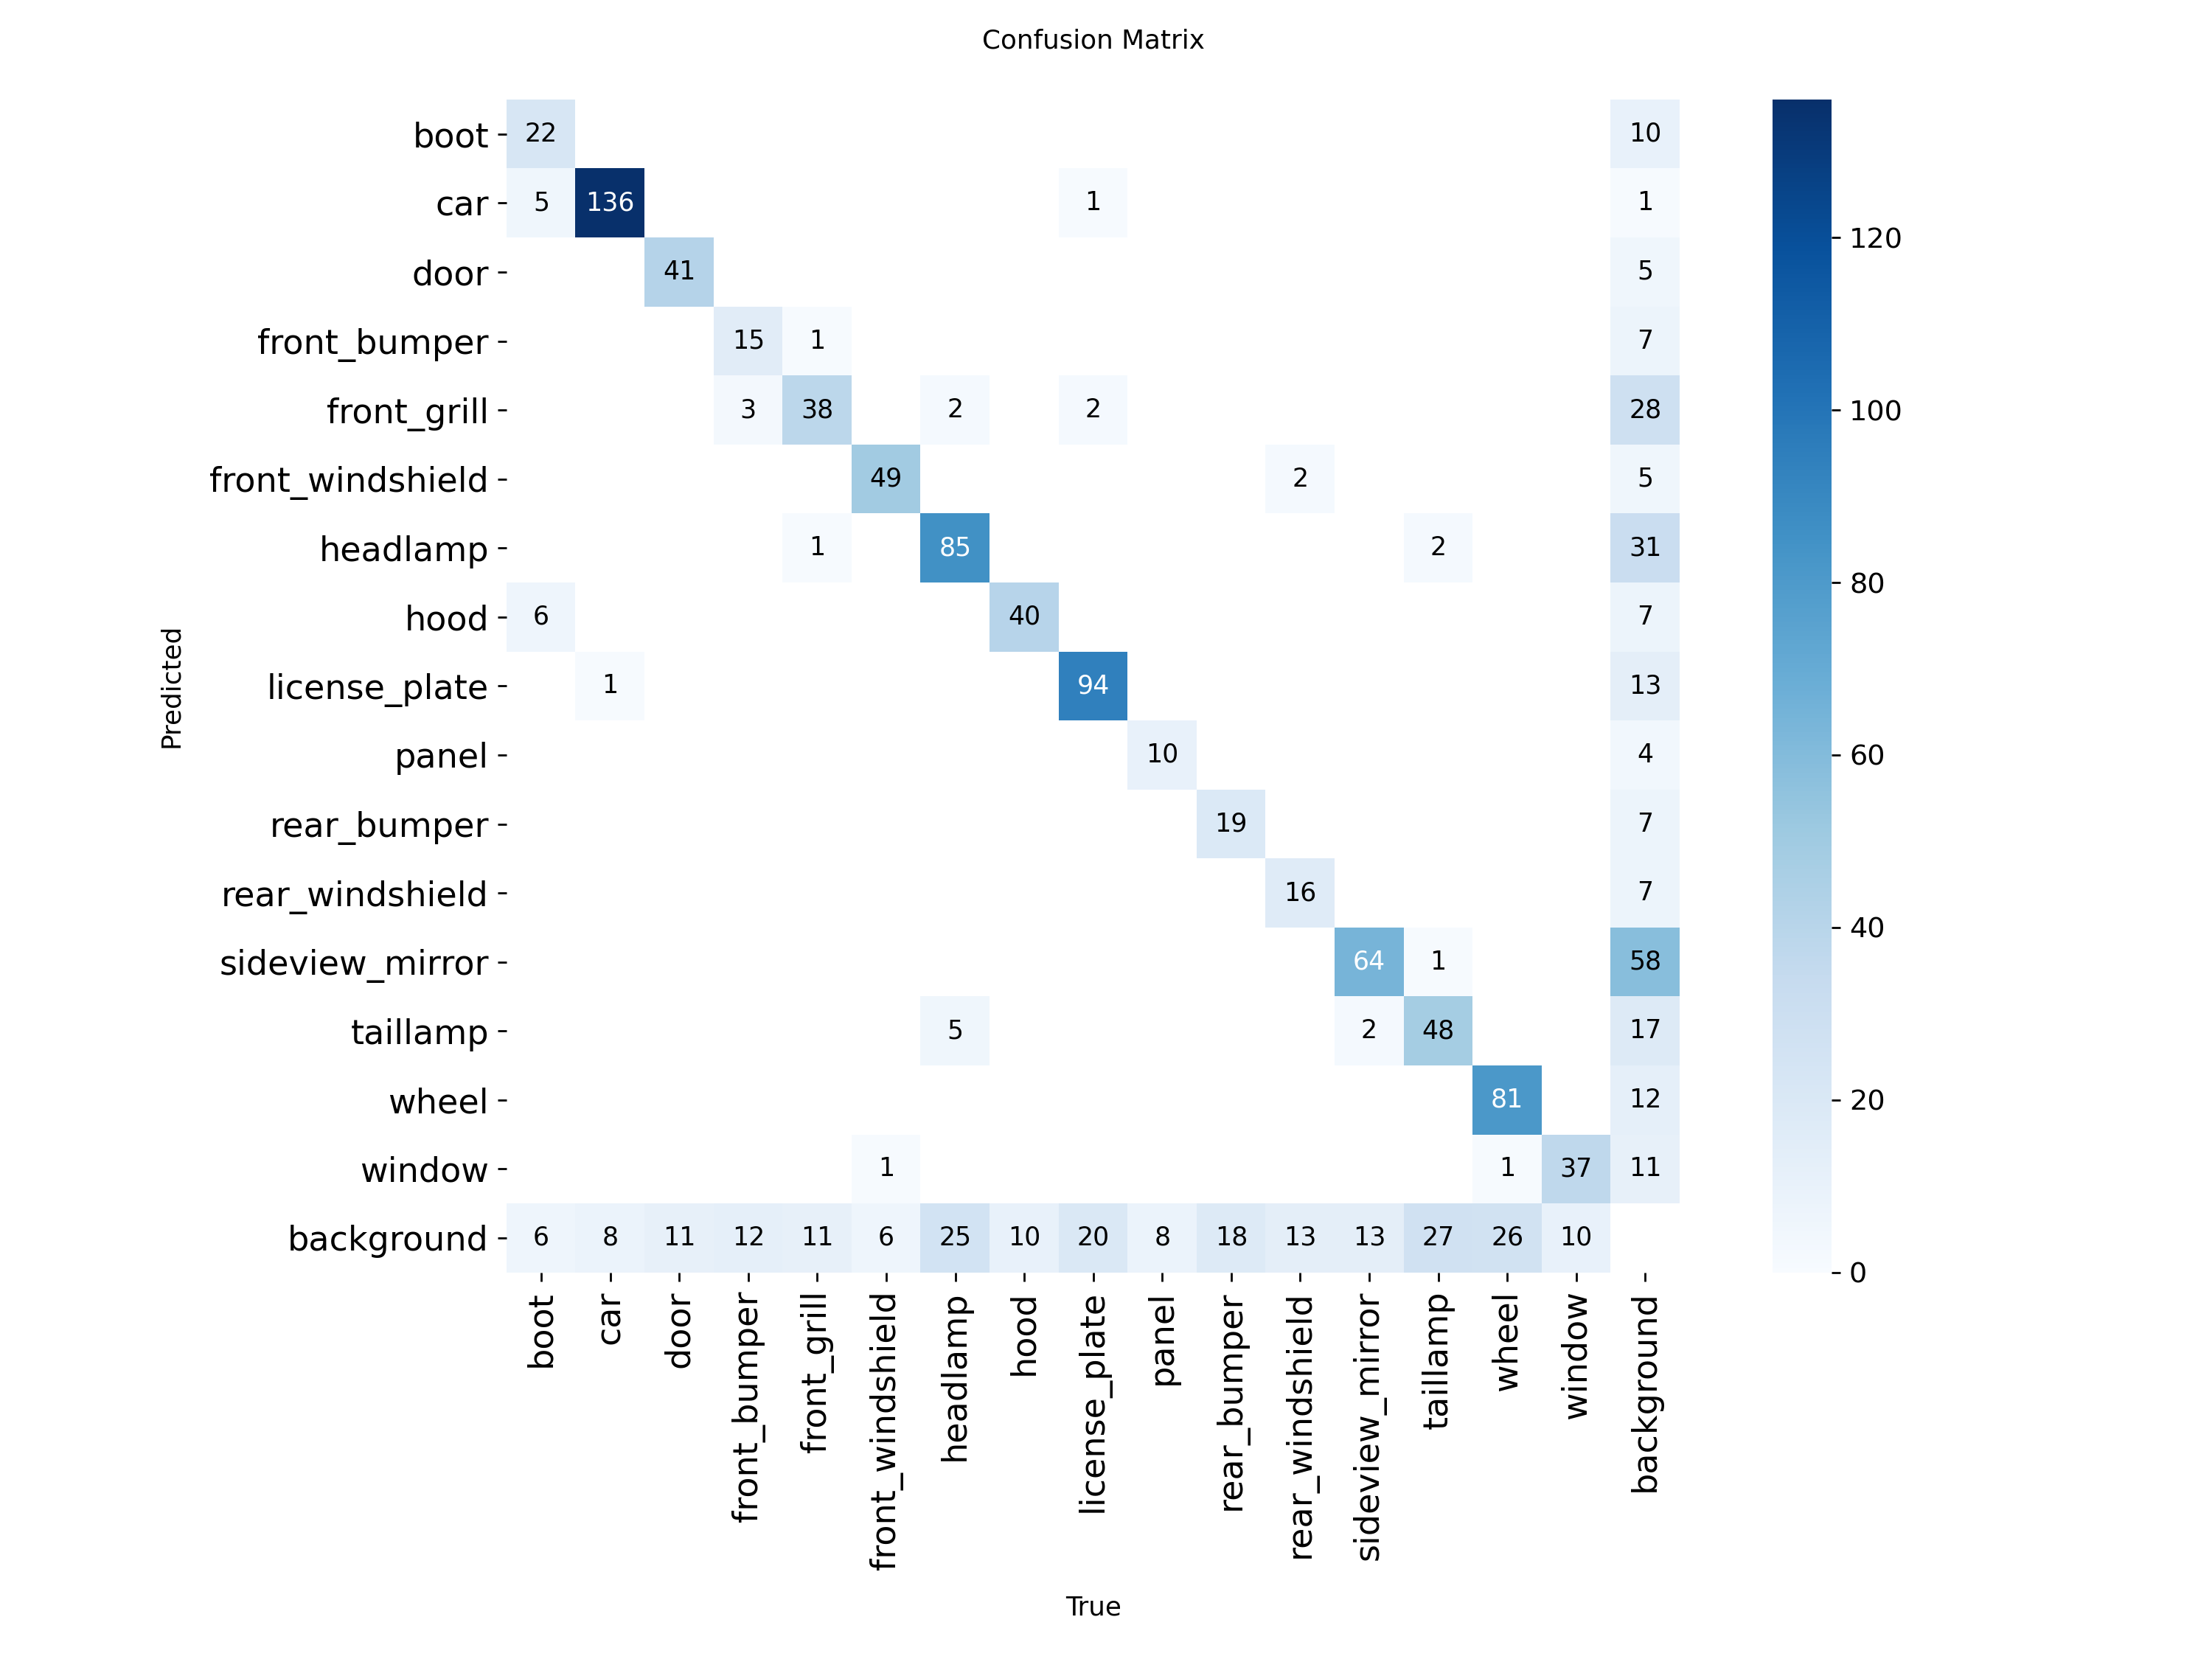

In [17]:
from IPython.display import Image, display

display(Image(filename='runs/detect/val/confusion_matrix.png', width=600))



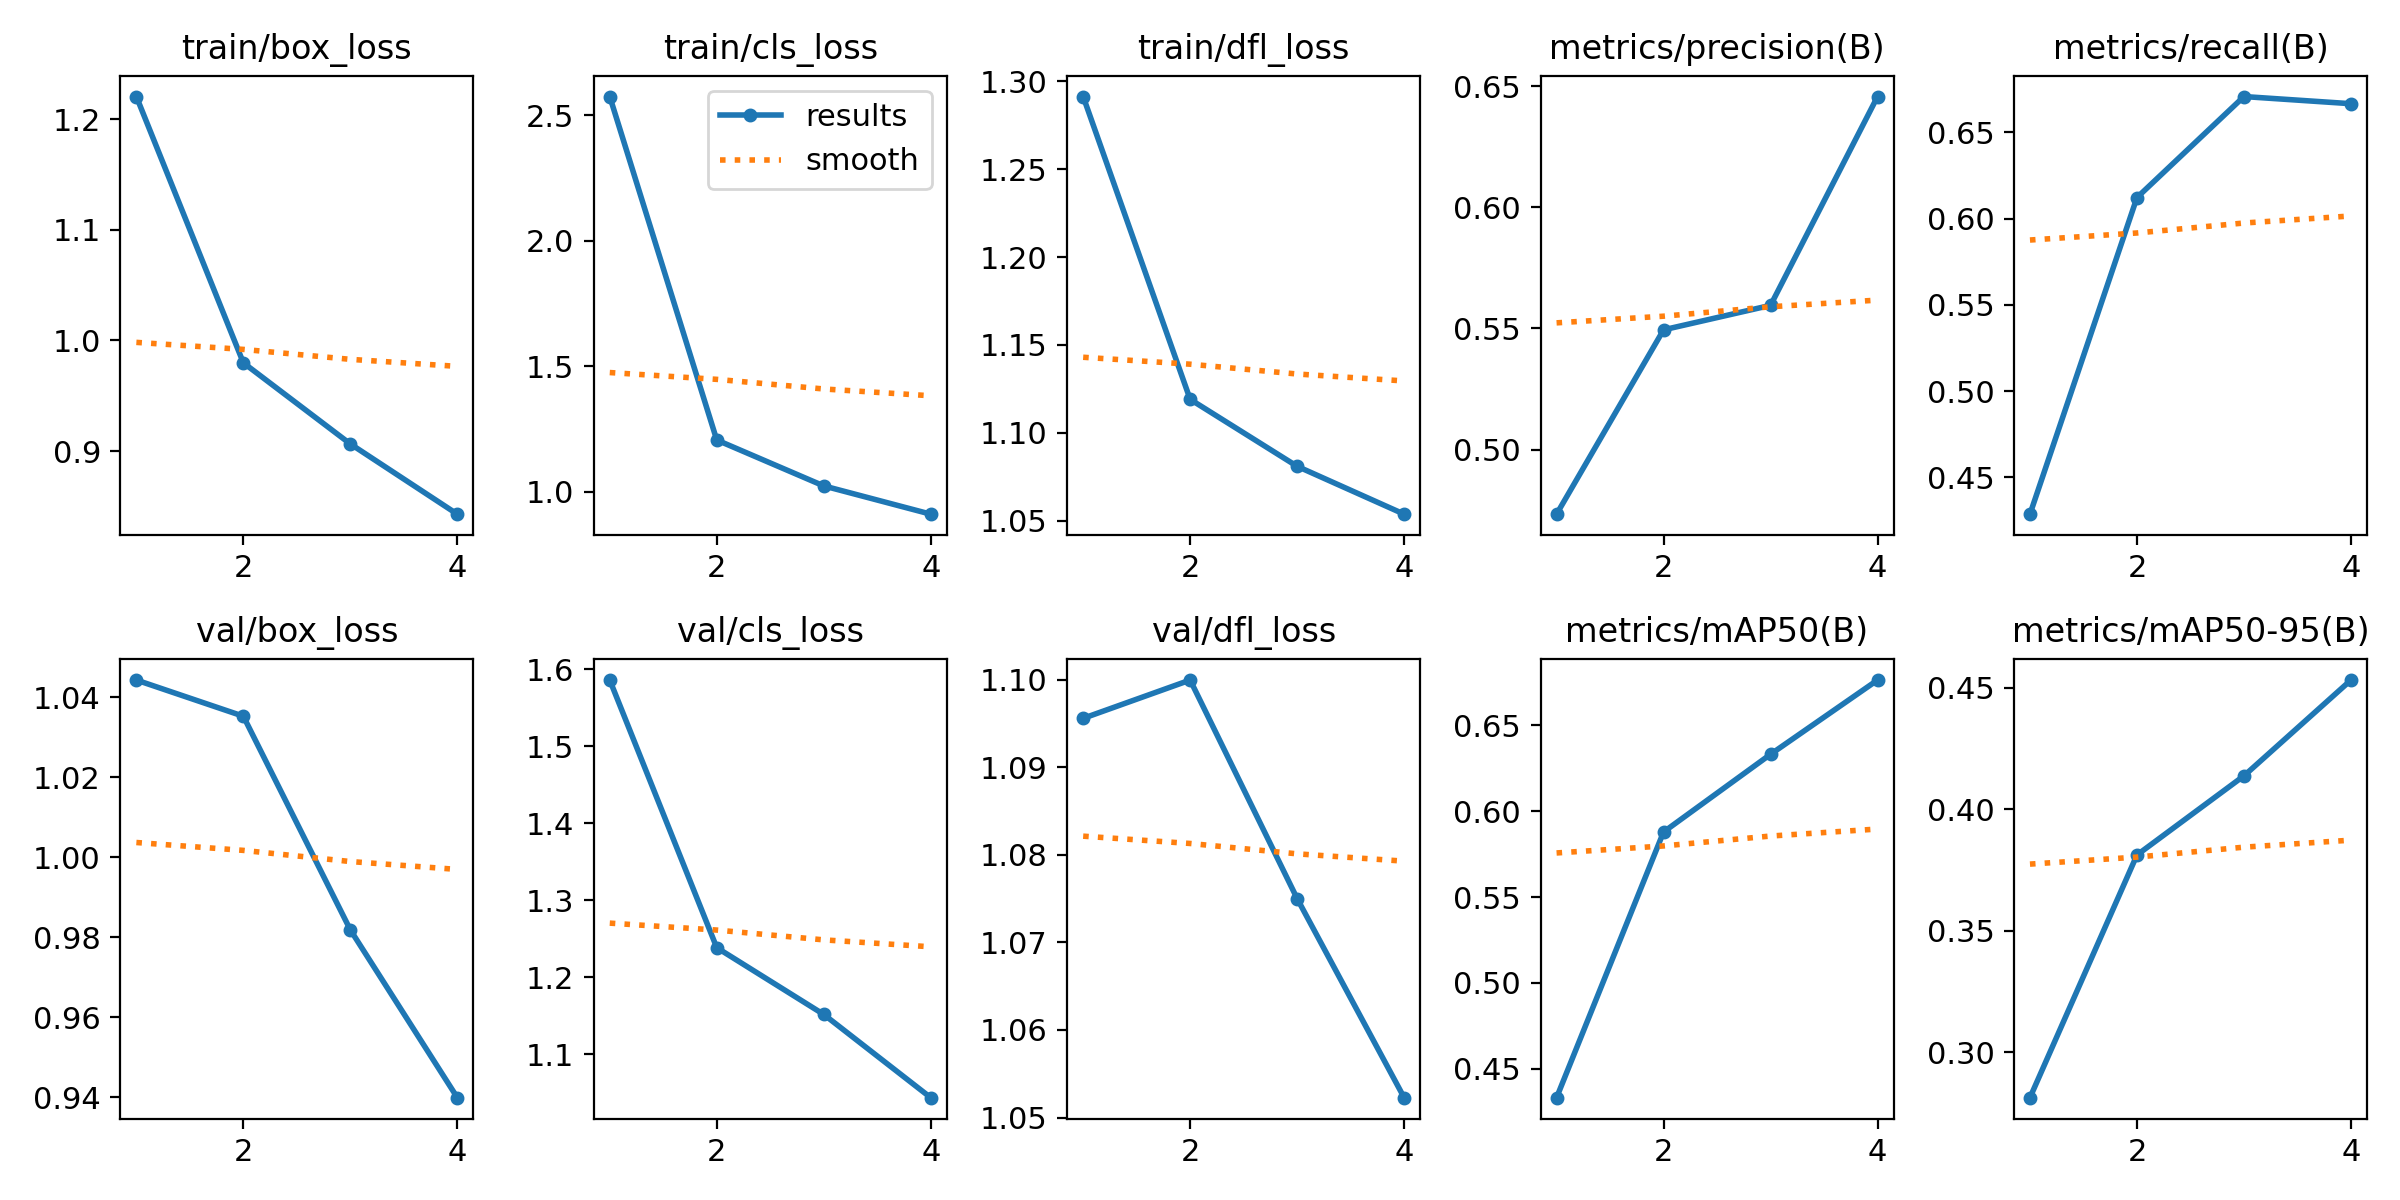

In [11]:
from IPython.display import Image, display
display(Image(filename='runs/detect/train3/results.png', width=600))
